In [54]:
import os
import io
import math
import random
import torch
import numpy as np
from collections import defaultdict
from typing import Optional
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from datasets import load_dataset, Image as HFImage
from PIL import Image as PILImage
from PIL import ImageStat, Image

# ============================================
# Configuración Básica
# ============================================
SEED = 7
BATCH_SIZE = 16       # Ajustado para seguridad
FINAL_SIZE = 256      # 256x256
NUM_WORKERS = 2
PIN_MEMORY = True
DROP_LAST = True

# Cantidad de datos
CONTENT_KEEP = 10_000 
STYLE_KEEP   = 15_000 

# Normalización
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ============================================
# Semillas
# ============================================
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def worker_seed_init(worker_id: int):
    seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(seed); random.seed(seed)

set_seed(SEED)

# ============================================
# Transforms (Tus transforms originales)
# ============================================
content_tf = transforms.Compose([
    transforms.RandomResizedCrop(FINAL_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

style_tf = transforms.Compose([
    transforms.RandomResizedCrop(FINAL_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ============================================
# Utilidades HF / PIL (Tu código original)
# ============================================
def detect_image_col(ds):
    for c in ["image", "coco_url", "url", "image_url", "filepath", "file_name", "path"]:
        if c in ds.column_names:
            return c
    raise RuntimeError(f"No image-like column found. Columns: {ds.column_names}")

def is_valid_image_entry(x):
    if x is None: return False
    if isinstance(x, list):
        if len(x) == 0: return False
        x = x[0]
    if hasattr(x, "size"):  # PIL.Image
        return True
    if isinstance(x, dict):
        return ("bytes" in x and x["bytes"] is not None) or ("path" in x and x["path"])
    if isinstance(x, (bytes, bytearray)): return True
    if isinstance(x, str): return x.startswith("http") or os.path.exists(x)
    return False

def filter_valid_images(ds, img_key):
    return ds.filter(lambda ex: is_valid_image_entry(ex[img_key]), num_proc=1)

def cast_to_image(ds, col_name):
    if col_name != "image":
        ds = ds.cast_column(col_name, HFImage(decode=True))
        ds = ds.rename_column(col_name, "image")
    else:
        ds = ds.cast_column("image", HFImage(decode=True))
    return ds

def to_pil(x):
    if isinstance(x, list) and len(x) > 0:
        x = x[0]
    if hasattr(x, "size"):  # PIL
        return x.convert("RGB")
    if isinstance(x, dict) and "bytes" in x and x["bytes"] is not None:
        return PILImage.open(io.BytesIO(x["bytes"])).convert("RGB")
    if isinstance(x, dict) and "path" in x and x["path"]:
        return PILImage.open(x["path"]).convert("RGB")
    if isinstance(x, (bytes, bytearray)):
        return PILImage.open(io.BytesIO(x)).convert("RGB")
    if isinstance(x, str) and (x.startswith("http") or os.path.exists(x)):
        return PILImage.open(x).convert("RGB")
    raise TypeError(f"No pude convertir a PIL: tipo={type(x)}")

# ============================================
# Dataset wrapper + collate
# ============================================
class HFDataset(torch.utils.data.Dataset):
    def __init__(self, hf_ds, img_key: str, transform):
        self.ds = hf_ds
        self.img_key = img_key
        self.tfm = transform
    def __len__(self):
        return self.ds.num_rows
    def __getitem__(self, idx):
        try:
            ex = self.ds[idx]
            img = to_pil(ex[self.img_key])
            return self.tfm(img)
        except Exception:
            # Fallback robusto por si una imagen falla individualmente
            return torch.zeros((3, FINAL_SIZE, FINAL_SIZE))

def collate_pixels(batch):
    return torch.stack(batch, dim=0)

# ============================================
# DataLoader optimizado
# ============================================
def make_loader(ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin=PIN_MEMORY,
                drop_last=DROP_LAST, collate_fn=collate_pixels):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin,
        drop_last=drop_last,
        collate_fn=collate_fn,
        persistent_workers=(num_workers > 0),
        prefetch_factor=4 if num_workers > 0 else None,
        worker_init_fn=worker_seed_init)

# ============================================
# Iterador dual
# ============================================
def infinite_cycle(loader):
    while True:
        for batch in loader:
            yield batch

class DualBatchIterator:
    def __init__(self, content_loader, style_loader):
        self.content_loader = content_loader
        self.style_iter = infinite_cycle(style_loader)

    def __iter__(self):
        for xb_content in self.content_loader:
            xb_style = next(self.style_iter)
            if xb_style.size(0) != xb_content.size(0):
                b = xb_content.size(0)
                if xb_style.size(0) > b:
                    xb_style = xb_style[:b]
                else:
                    idx = torch.randint(0, xb_style.size(0), (b,), device=xb_style.device)
                    xb_style = xb_style.index_select(0, idx)
            yield xb_content, xb_style

def make_train_iterator(content_loader, style_loader):
    return DualBatchIterator(content_loader, style_loader)

# ============================================
# Funciones de Recorte y Muestreo
# ============================================
def truncate_dataloaders(content_loader: DataLoader,
                         style_loader: Optional[DataLoader] = None,
                         n: int = 60000,
                         seed: int = 77):
    rng = np.random.default_rng(seed)

    def sample_indices(ds_len, n_keep):
        n_keep = min(int(n_keep), int(ds_len))
        return rng.choice(ds_len, size=n_keep, replace=False)

    def shrink_dataset_from_loader(loader, n_keep):
        ds = loader.dataset
        if hasattr(ds, "ds"):  
            base = ds.ds
            idx = sample_indices(len(base), n_keep)
            base_small = base.select(idx.tolist())
            ds_small = type(ds)(base_small, img_key=ds.img_key, transform=ds.tfm)
        else:
            idx = sample_indices(len(ds), n_keep)
            ds_small = Subset(ds, idx)

        return make_loader(
            ds_small,
            batch_size=loader.batch_size,
            num_workers=loader.num_workers,
            pin=loader.pin_memory,
            drop_last=loader.drop_last,
            collate_fn=loader.collate_fn)

    content_small = shrink_dataset_from_loader(content_loader, n)
    if style_loader is None:
        return content_small
    style_small = shrink_dataset_from_loader(style_loader, n)
    return content_small, style_small

def stratified_pick(hf_ds, group_col: str, target_total: int, seed: int = 77, min_per_group: int = 1):
    if group_col not in hf_ds.column_names:
        raise ValueError(f"'{group_col}' no está en {hf_ds.column_names}")
    rng = np.random.default_rng(seed)

    buckets = defaultdict(list)
    for i, g in enumerate(hf_ds[group_col]):
        if g is not None:
            buckets[g].append(i)

    G = len(buckets)
    if G == 0:
        n = min(target_total, len(hf_ds))
        return rng.choice(len(hf_ds), size=n, replace=False).tolist()

    per_group = max(min_per_group, math.ceil(target_total / G))

    picked = []
    for _, idxs in buckets.items():
        if len(picked) >= target_total:
            break
        if len(idxs) <= per_group:
            picked.extend(idxs)
        else:
            picked.extend(rng.choice(idxs, size=per_group, replace=False).tolist())

    if len(picked) > target_total:
        picked = rng.choice(picked, size=target_total, replace=False).tolist()

    return sorted(picked)

def calculate_image_metrics(pil_img, thumb_size=128):
    pil_img = pil_img.convert("RGB") 
    img_small = pil_img.resize((thumb_size, thumb_size))
    
    # Entropía (Textura)
    gray_img = img_small.convert("L")
    histogram = gray_img.histogram()
    histogram_length = sum(histogram)
    samples_probability = [float(h) / histogram_length for h in histogram]
    entropy = -sum([p * math.log(p, 2) for p in samples_probability if p != 0])
    
    # Saturación (Color)
    hsv_img = img_small.convert("HSV")
    stat = ImageStat.Stat(hsv_img)
    avg_saturation = stat.mean[1] # Rango 0-255
    
    return entropy, avg_saturation

def is_good_style_image(example, entropy_th=4.2, saturation_th=15):
    """
    Versión RELAJADA para evitar vaciar el dataset.
    - entropy_th: 3.5 (Acepta paisajes suaves pero rechaza planos puros)
    - saturation_th: 10 (Acepta colores pasteles o apagados, rechaza B/N puro)
    """
    try:
        img = example["image"]
        # Manejo robusto si no es PIL todavía
        if not hasattr(img, "convert"): 
            img = to_pil(img)
            
        ent, sat = calculate_image_metrics(img)
        
        return (ent > entropy_th) and (sat > saturation_th)
    except Exception as e:
        
        return False


# ============================================
# Carga de Datos (Lógica Mejorada)
# ============================================

# 1. COCO (Tu versión exacta, que confirmas que funciona)
print(">>> Cargando COCO (phiyodr/coco2017)...")
coco_hf = load_dataset("phiyodr/coco2017", split="train")
coco_img_col = detect_image_col(coco_hf)
coco_hf = filter_valid_images(coco_hf, coco_img_col)
coco_hf = cast_to_image(coco_hf, coco_img_col) # Esto fuerza el decode que necesitas
coco_ds = HFDataset(coco_hf, img_key="image", transform=content_tf)
content_loader = make_loader(coco_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

# 2. WIKIART (Con filtro inteligente de géneros)
print(">>> Cargando WikiArt...")
wiki_hf = load_dataset("davanstrien/wikiart-resized", split="train")
wiki_img_col = detect_image_col(wiki_hf)
wiki_hf = filter_valid_images(wiki_hf, wiki_img_col)
wiki_hf = cast_to_image(wiki_hf, wiki_img_col) 

# FILTRO DE GÉNEROS
GOOD_STYLES = [
    "impressionism", "expressionism", "post_impressionism", 
    "realism", "romanticism", "baroque", "rococo", 
    "northern_renaissance", "early_renaissance", "high_renaissance",
    "fauvism", "cubism", "symbolism", "art_nouveau_modern", "ukiyo_e"]

style_names = wiki_hf.features["style"].names
valid_ids = set()
for idx, name in enumerate(style_names):
    name_norm = name.lower().replace("-", "_").replace(" ", "_")
    if any(gs in name_norm for gs in GOOD_STYLES):
        valid_ids.add(idx)

print(f"   Filtrando por género... (Total original: {len(wiki_hf)})")
wiki_filtered = wiki_hf.filter(lambda x: x["style"] in valid_ids, num_proc=NUM_WORKERS)

# FILTRO ESTADÍSTICO 

print(f"   Aplicando filtro de calidad (Entropía > 3.5, Sat > 10)...")
wiki_high_quality = wiki_filtered.filter(
    lambda x: is_good_style_image(x, entropy_th=3.5, saturation_th=10),num_proc=1)

count_hq = len(wiki_high_quality)
print(f"   Estilos de ALTA CALIDAD restantes: {count_hq}")

if count_hq == 0:
    raise ValueError("¡El filtro eliminó todas las imágenes! Baja los thresholds de entropía/saturación.")

# MUESTREO ESTRATIFICADO 
target_final = min(STYLE_KEEP, count_hq) 

try:
    print(f"   Aplicando muestreo estratificado para obtener {target_final} imágenes...")
    idx_keep = stratified_pick(wiki_high_quality, group_col="artist", target_total=target_final, seed=77)
except ValueError:
    print("   Artist column missing, estratificando por estilo...")
    idx_keep = stratified_pick(wiki_high_quality, group_col="style", target_total=target_final, seed=77)

wiki_hf_small = wiki_high_quality.select(idx_keep)


wiki_ds = HFDataset(wiki_hf_small, img_key="image", transform=style_tf)
style_loader = make_loader(wiki_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

# Recorte final contenido
content_loader = truncate_dataloaders(content_loader, None, n=CONTENT_KEEP, seed=77)
train_iter = make_train_iterator(content_loader, style_loader)

print(">>> Probando batch...")
xb_c, xb_s = next(iter(train_iter))
print("paired content:", xb_c.shape, f"Min: {xb_c.min():.2f} Max: {xb_c.max():.2f}")
print("paired style:  ", xb_s.shape, f"Min: {xb_s.min():.2f} Max: {xb_s.max():.2f}")
print("len(content_loader) =", len(content_loader))

>>> Cargando COCO (phiyodr/coco2017)...
>>> Cargando WikiArt...
   Filtrando por género... (Total original: 38634)
   Aplicando filtro de calidad (Entropía > 3.5, Sat > 10)...
   Estilos de ALTA CALIDAD restantes: 31922
   Aplicando muestreo estratificado para obtener 15000 imágenes...
>>> Probando batch...
paired content: torch.Size([16, 3, 256, 256]) Min: -2.12 Max: 2.64
paired style:   torch.Size([16, 3, 256, 256]) Min: -2.10 Max: 2.59
len(content_loader) = 625


---


In [39]:
def analyze_loader(name, loader):
    print(f"\n===== Análisis del loader: {name} =====")

    total_imgs = len(loader.dataset)
    print(f"Total de imágenes: {total_imgs}")

    num_batches = len(loader)
    print(f"Número de batches: {num_batches}")

    batch = next(iter(loader))
    print(f"Batch shape: {batch.shape}")
    print(f"dtype: {batch.dtype}")

    print(f"min pixel: {batch.min().item():.4f}")
    print(f"max pixel: {batch.max().item():.4f}")
    print(f"mean: {batch.mean().item():.4f}")
    print(f"std:  {batch.std().item():.4f}")

    print("NaNs:", torch.isnan(batch).any().item())
    print("Infs:", torch.isinf(batch).any().item())

    print("mean por canal:", batch.mean(dim=(0,2,3)))
    print("std por canal:", batch.std(dim=(0,2,3)))


analyze_loader("CONTENT (COCO)", content_loader)
analyze_loader("STYLE (WikiArt)", style_loader)


===== Análisis del loader: CONTENT (COCO) =====
Total de imágenes: 10000
Número de batches: 625
Batch shape: torch.Size([16, 3, 256, 256])
dtype: torch.float32
min pixel: -2.1179
max pixel: 2.6400
mean: 0.0943
std:  1.0854
NaNs: False
Infs: False
mean por canal: tensor([0.0072, 0.0848, 0.1908])
std por canal: tensor([1.1253, 1.0625, 1.0592])

===== Análisis del loader: STYLE (WikiArt) =====
Total de imágenes: 9051
Número de batches: 565
Batch shape: torch.Size([16, 3, 256, 256])
dtype: torch.float32
min pixel: -2.1008
max pixel: 2.6400
mean: 0.0835
std:  1.1107
NaNs: False
Infs: False
mean por canal: tensor([ 0.1413,  0.1313, -0.0222])
std por canal: tensor([1.0588, 1.0936, 1.1692])


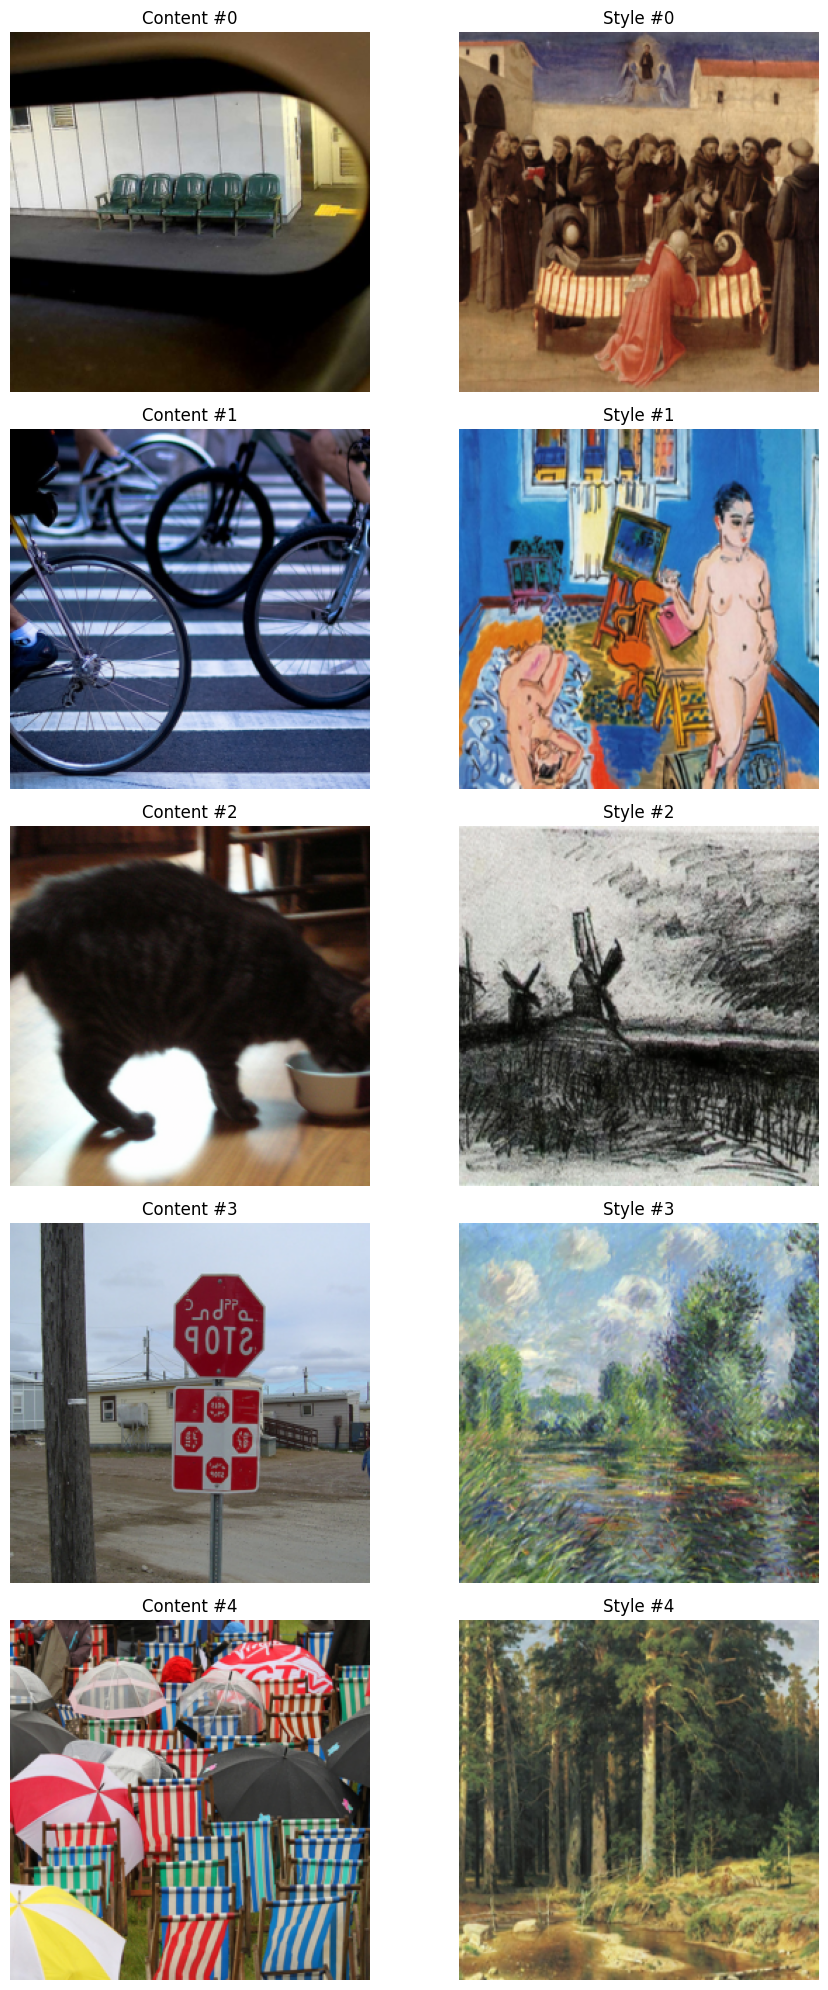

In [26]:
import matplotlib.pyplot as plt

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(x):
    """x: tensor [3,H,W] normalizado → tensor [H,W,3] en [0,1]"""
    x = x.cpu() * IMAGENET_STD + IMAGENET_MEAN
    x = x.clamp(0,1)
    return x.permute(1,2,0).numpy()

def show_examples(train_iter, num_pairs=5):
    """
    Muestra num_pairs de pares (content, style) obtenidos del DualBatchIterator.
    """
    x_content, x_style = next(iter(train_iter))
    num_pairs = min(num_pairs, x_content.size(0), x_style.size(0))

    plt.figure(figsize=(10, 4*num_pairs))

    for i in range(num_pairs):

        plt.subplot(num_pairs, 2, 2*i + 1)
        plt.imshow(denorm(x_content[i]))
        plt.title(f"Content #{i}")
        plt.axis("off")

        plt.subplot(num_pairs, 2, 2*i + 2)
        plt.imshow(denorm(x_style[i]))
        plt.title(f"Style #{i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(train_iter, num_pairs=5)

---


In [27]:
import torch
import torch.nn as nn
import torchvision.models as models

# Mapeo estándar VGG19 (Features block)
VGG19_IDX2NAME = {
    0: "conv1_1", 1: "relu1_1", 2: "conv1_2", 3: "relu1_2", 4: "pool1",
    5: "conv2_1", 6: "relu2_1", 7: "conv2_2", 8: "relu2_2", 9: "pool2",
    10: "conv3_1", 11: "relu3_1", 12: "conv3_2", 13: "relu3_2",
    14: "conv3_3", 15: "relu3_3", 16: "conv3_4", 17: "relu3_4", 18: "pool3",
    19: "conv4_1", 20: "relu4_1", 21: "conv4_2", 22: "relu4_2",
    23: "conv4_3", 24: "relu4_3", 25: "conv4_4", 26: "relu4_4", 27: "pool4",
    28: "conv5_1", 29: "relu5_1", 30: "conv5_2", 31: "relu5_2",
    32: "conv5_3", 33: "relu5_3", 34: "conv5_4", 35: "relu5_4", 36: "pool5"}

VGG19_NAME2IDX = {v: k for k, v in VGG19_IDX2NAME.items()}

class VGGEncoder(nn.Module):
    def __init__(self, layers_to_extract=None, device="cuda"):
        super().__init__()

        weights = models.VGG19_Weights.IMAGENET1K_V1
        vgg = models.vgg19(weights=weights).features
        
        for name, layer in vgg.named_children():
            if isinstance(layer, nn.ReLU):
                layer.inplace = False
        
        self.vgg_layers = vgg
        self.device = device
        
        if layers_to_extract is None:
            self.target_layers = ["relu1_1", "relu2_1", "relu3_1", "relu4_1", "relu5_1"]
        else:
            self.target_layers = layers_to_extract

        self.target_indices = {VGG19_NAME2IDX[n]: n for n in self.target_layers}
        self.max_idx = max(self.target_indices.keys())
        
        for param in self.parameters():
            param.requires_grad = False
            
        self.to(device)
        self.eval()

    def forward(self, x):
        """
        Entrada: x (Tensor normalizado con ImageNet stats)
        Salida: Diccionario { 'relu1_1': tensor, ... }
        """
        outputs = {}
        
        for i, layer in enumerate(self.vgg_layers):
            x = layer(x)
            
            if i in self.target_indices:
                layer_name = self.target_indices[i]
                outputs[layer_name] = x

            if i >= self.max_idx:
                break
                
        return outputs

def get_vgg_encoder(device):
    targets = ["relu1_1", "relu2_1", "relu3_1", "relu4_1", "relu5_1"]
    return VGGEncoder(layers_to_extract=targets, device=device)

In [28]:

import torch
import torch.nn as nn
import math 

class StyA2KAttentionFusion(nn.Module):
    def __init__(self, in_channels=512):
        super().__init__()
        self.in_channels = in_channels
        
        # BLOQUE DE ATENCIÓN 
        self.f_query = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.f_key   = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.f_value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        
        self.softmax = nn.Softmax(dim=-1)
        
        # FUSION LAYER 
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(in_channels * 2, in_channels, kernel_size=1),
            nn.InstanceNorm2d(in_channels, affine=True), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=1))

    def mean_variance_norm(self, feat):
        size = feat.size()
        mean, std = self.calc_mean_std(feat)
        normalized_feat = (feat - mean.expand(size)) / (std.expand(size) + 1e-5)
        return normalized_feat

    def calc_mean_std(self, feat, eps=1e-5):
        size = feat.size()
        N, C = size[:2]
        feat_var = feat.view(N, C, -1).var(dim=2) + eps
        feat_std = feat_var.sqrt().view(N, C, 1, 1)
        feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
        return feat_mean, feat_std

    def forward(self, content_feat, style_feat):
        B, C, H, W = content_feat.size()
        
        # Normalización (Para calcular similitud semántica, no magnitud)
        norm_content = self.mean_variance_norm(content_feat)
        norm_style   = self.mean_variance_norm(style_feat)
        
        # Proyecciones
        query = self.f_query(norm_content).view(B, C, -1).permute(0, 2, 1) # (B, HW, C)
        key   = self.f_key(norm_style).view(B, C, -1)                      # (B, C, HW)
        
        # Escalamos por la raíz cuadrada de C para evitar saturar el Softmax
        energy = torch.bmm(query, key) / math.sqrt(C) 
        attention = self.softmax(energy) 
        
        # Values (Usamos features originales para mantener textura real)
        value = self.f_value(style_feat).view(B, C, -1) 
        
        # Aplicar atención
        attended_style = torch.bmm(value, attention.permute(0, 2, 1)).view(B, C, H, W)
        
        # Fusión
        combined = torch.cat([content_feat, attended_style], dim=1)
        out = self.fusion_conv(combined)
        
        return out + content_feat



In [30]:
class StyA2KDecoderMultiLevel(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Bloque 4 (512 -> 256) ---
        self.block4_up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 32->64
            ConvBlock(512, 256),
            ConvBlock(256, 256),
            ConvBlock(256, 256))

        #  Mixer Layer 
        # Aquí mezclamos lo que viene de arriba con la fusión del nivel 3
        # Entrada: 256 (del block4) + 256 (de la fusión nivel 3) = 512
        self.mix_3 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True))

        # Bloque 3 (256 -> 128) 
        self.block3_up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 64->128
            ConvBlock(256, 128),
            ConvBlock(128, 128))

        # Bloque 2 (128 -> 64) 
        self.block2_up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 128->256
            ConvBlock(128, 64),
            ConvBlock(64, 64))
        
        self.out_conv = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(64, 3, kernel_size=3, padding=0))

    def forward(self, x_fused_4, x_fused_3):
        """
        x_fused_4: [B, 512, 32, 32] -> Viene de fusión relu4_1
        x_fused_3: [B, 256, 64, 64] -> Viene de fusión relu3_1
        """
        
        #  Procesar nivel 4 y subir resolución
        h = self.block4_up(x_fused_4) # Salida: [B, 256, 64, 64]
        
        # Concatenamos con la fusión del nivel 3
        h_cat = torch.cat([h, x_fused_3], dim=1) # [B, 512, 64, 64]
        h = self.mix_3(h_cat)                    # [B, 256, 64, 64]
        
        h = self.block3_up(h) # [B, 128, 128, 128]
        h = self.block2_up(h)  # [B, 64, 256, 256]
        
        return self.out_conv(h) # [B, 3, 256, 256]

In [31]:
class StyA2KNet(nn.Module):
    def __init__(self, encoder, device="cuda"):
        """
        ARGS:
            encoder: Instancia de VGGEncoder (debe extraer relu3_1 y relu4_1).
        """
        super().__init__()
        self.device = device
        self.vgg_encoder = encoder
        
        # Congelar VGG (Seguridad)
        for param in self.vgg_encoder.parameters():
            param.requires_grad = False
        
        # --- DOS MÓDULOS DE ATENCIÓN ---
        self.fusion4 = StyA2KAttentionFusion(in_channels=512)
        
        # Uno para el color y textura fina 
        self.fusion3 = StyA2KAttentionFusion(in_channels=256)
        
        #Decoder Multi-Nivel
        self.decoder = StyA2KDecoderMultiLevel()
        
        self.to(device)

    def encode_multi(self, x):
        """Helper para extraer ambos niveles a la vez"""
        features = self.vgg_encoder(x)
        return features["relu4_1"], features["relu3_1"]

    
    def forward(self, x_content, x_style, alpha=1.0):
        
        # Extracción de Features (Multi-Nivel)
        with torch.no_grad():
            # Obtenemos features profundas (c4) y medias (c3)
            c4, c3 = self.encode_multi(x_content)
            s4, s3 = self.encode_multi(x_style)
        
        # Fusión Nivel 4 (Estructura global)
        F_stylized_4 = self.fusion4(c4, s4)
        
        # Fusión Nivel 3 (Color y Detalle)
        F_stylized_3 = self.fusion3(c3, s3)
        
        # Control de Alpha (Interpolación)
        if alpha < 1.0:
            F_stylized_4 = alpha * F_stylized_4 + (1 - alpha) * c4
            F_stylized_3 = alpha * F_stylized_3 + (1 - alpha) * c3
            
        output_image = self.decoder(F_stylized_4, F_stylized_3)
        
        return output_image

---


In [32]:
def gram_matrix_optimized(input_tensor):
    """
    Calcula Gram Matrix normalizada SOLO por tamaño espacial.
    Esto evita que los valores se vuelvan infinitesimales.
    """
    B, C, H, W = input_tensor.size()
    features = input_tensor.view(B, C, H * W)
    G = torch.bmm(features, features.transpose(1, 2)) 
    
    return G.div(H * W)


class StyleTransferLoss(nn.Module):
    def __init__(self, encoder, content_weight=1.0, style_weight=5.0, tv_weight=1e-5, style_layer_weights=None, moment_weight=1.0):
        """
        ARGS:
            moment_weight (float): Peso extra para forzar coincidencia de Media/Std (Color).
                                   Recomendado: 1.0 a 5.0 si quieres mucho color.
        """
        super().__init__()
        self.encoder = encoder
        
        # Pesos globales
        self.cw = content_weight
        self.sw = style_weight
        self.tvw = tv_weight
        self.mw  = moment_weight # Peso de momentos (Color)
        
        if style_layer_weights is None:
            self.style_layer_weights = {
                'relu1_1': 1.0, 
                'relu2_1': 1.0, 
                'relu3_1': 1.0, 
                'relu4_1': 1.0}
        else:
            self.style_layer_weights = style_layer_weights
        
        self.mse = nn.MSELoss()
        
        # Constantes ImageNet
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def normalize_prediction(self, img_0_1):
        return (img_0_1 - self.mean) / self.std

    def calculate_tv(self, img):
        return (torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:])) + 
                torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))) / img.numel()

    def calc_mean_std(self, feat, eps=1e-5):
        """Calcula media y desviación estándar espacial."""
        size = feat.size()
        N, C = size[:2]
        feat_var = feat.view(N, C, -1).var(dim=2) + eps
        feat_std = feat_var.sqrt().view(N, C, 1, 1)
        feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
        return feat_mean, feat_std

    
    def forward(self, pred_logits, target_content_norm, target_style_norm):
        
        pred_img_0_1 = torch.sigmoid(pred_logits)
        pred_norm = self.normalize_prediction(pred_img_0_1)
        
        # Concatenar para una sola pasada
        full_batch = torch.cat([pred_norm, target_content_norm, target_style_norm], dim=0)
        feats = self.encoder(full_batch)
        
        # Separar
        b = pred_logits.size(0)
        f_pred = {k: v[:b] for k, v in feats.items()}
        f_cont = {k: v[b:2*b] for k, v in feats.items()}
        f_styl = {k: v[2*b:] for k, v in feats.items()}
        
        #  CONTENT LOSS 
        loss_c = self.mse(f_pred['relu4_1'], f_cont['relu4_1'].detach())
        
        # STYLE LOSS (Gram + Momentos) 
        loss_s = 0.0
        
        for layer, w in self.style_layer_weights.items():
            if layer in f_pred:
                # GRAM LOSS (Textura)
                gp = gram_matrix_optimized(f_pred[layer])
                gs = gram_matrix_optimized(f_styl[layer])
                loss_gram = self.mse(gp, gs.detach())
                
                # MOMENT LOSS (Color y Atmósfera) 
                # Calculamos media y std de la predicción y el target
                m_pred, s_pred = self.calc_mean_std(f_pred[layer])
                m_styl, s_styl = self.calc_mean_std(f_styl[layer])
                
                loss_moments = self.mse(m_pred, m_styl.detach()) + self.mse(s_pred, s_styl.detach())
                
                loss_s += w * (loss_gram + (self.mw * loss_moments))
            
        #  TV LOSS 
        loss_tv = self.calculate_tv(pred_img_0_1)
        
        total_loss = (self.cw * loss_c) + (self.sw * loss_s) + (self.tvw * loss_tv)
        
        return total_loss, {
            "total": total_loss.item(),
            "content": loss_c.item(),
            "style": loss_s.item(),
            "tv": loss_tv.item()}

---


In [33]:
import inspect
from contextlib import contextmanager, nullcontext
import torch

_DTYPE_MAP = {
    "bf16": torch.bfloat16,
    "bfloat16": torch.bfloat16,
    "fp16": torch.float16,
    "float16": torch.float16,}


def _cuda_dtype_supported(dtype: torch.dtype) -> bool:
    if not torch.cuda.is_available():
        return False

    return dtype in (torch.bfloat16, torch.float16)


def make_grad_scaler(device: str = "cuda", enabled: bool = True):
    """
    Devuelve un GradScaler compatible con tu versión de PyTorch.
    - Si AMP no está habilitado, devuelve None.
    - Soporta torch.amp.GradScaler('cuda'|'cpu') o sin args.
    """
    if not enabled:
        return None

    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        try:
            sig = inspect.signature(torch.amp.GradScaler)
            if len(sig.parameters) >= 1:
                return torch.amp.GradScaler(device if device in ("cuda", "cpu") else "cuda")
            else:
                return torch.amp.GradScaler()
        except Exception:
            pass

    if hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "GradScaler"):
        return torch.cuda.amp.GradScaler()

    return None

@contextmanager
def autocast_ctx(
    device: str = "cuda",
    enabled: bool = True,
    dtype: str = "bf16",          # "bf16" recomendado en A100
    cache_enabled: bool = True):
  
    """
    Contexto robusto para autocast:
      - CUDA: torch.amp.autocast(device_type="cuda", dtype=...)
      - CPU:  torch.amp.autocast(device_type="cpu",  dtype=torch.bfloat16) si enabled
      - fallback: nullcontext().

    Notas:
      * En BF16 NO uses GradScaler.
      * En FP16 sí puedes usar GradScaler (torch.amp.GradScaler / torch.cuda.amp.GradScaler).
    """
    if not enabled:
        with nullcontext():
            yield
        return

    if device == "cuda":
        want = _DTYPE_MAP.get(dtype.lower(), torch.bfloat16)
        use = want if _cuda_dtype_supported(want) else torch.float16
        with torch.amp.autocast(device_type="cuda", dtype=use, cache_enabled=cache_enabled):
            yield
        return

    if device == "cpu":
        try:
            with torch.amp.autocast(device_type="cpu", dtype=torch.bfloat16, cache_enabled=cache_enabled):
                yield
        except Exception:
            # fallback seguro si el backend no soporta cpu autocast
            with nullcontext():
                yield
        return

    with nullcontext():
        yield

In [34]:
def save_checkpoint(
    path: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler=None,
    epoch: int = 0,
    global_step: int = 0,
    extra: dict | None = None):
    
    """
    Guarda un checkpoint de entrenamiento completo.

    Parámetros
    ----------
    path : str
        Ruta destino (ej. 'checkpoints/stya2k_e005.pt').
    model : nn.Module
        Modelo (puede ser DataParallel).
    optimizer : Optimizer
        Optimizador.
    scaler : GradScaler o None
        Escalador de AMP si usas FP16.
    epoch, global_step : int
        Progreso actual.
    extra : dict
        Metadatos adicionales opcionales (por ej. métricas).
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)

    # si es DataParallel, acceder al modelo interno
    model_to_save = model.module if hasattr(model, "module") else model

    checkpoint = {
        "model": model_to_save.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
        "extra": extra or {}}

    if scaler is not None:
        checkpoint["scaler"] = scaler.state_dict()

    torch.save(checkpoint, path)
    print(f"[CKPT] Guardado en {path}")

def load_checkpoint(
    path: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
    scaler=None,
    device: str = "cuda"):
    
    """
    Carga un checkpoint y restaura modelo/optimizador/escalador.

    Devuelve: (epoch, global_step, extra)
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encontró el checkpoint: {path}")

    ckpt = torch.load(path, map_location=device)

    model_to_load = model.module if hasattr(model, "module") else model
    model_to_load.load_state_dict(ckpt["model"], strict=True)
    print(f"[CKPT] Modelo cargado desde {path}")

    if optimizer is not None and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
        print("[CKPT] Optimizador restaurado")

    if scaler is not None and "scaler" in ckpt:
        scaler.load_state_dict(ckpt["scaler"])
        print("[CKPT] GradScaler restaurado")

    epoch = ckpt.get("epoch", 0)
    global_step = ckpt.get("global_step", 0)
    extra = ckpt.get("extra", {})

    print(f"[CKPT] Epoch={epoch}, Global step={global_step}")
    return epoch, global_step, extra


In [35]:
def train_one_epoch(
    model,
    criterion,
    optimizer,
    train_iter,
    steps_per_epoch: int,
    device: str,
    log_every: int = 50,
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",   # "bf16" o "fp16"
    scaler=None,
    grad_clip: float | None = None,):

    """
    Entrena StyA2KNet por 1 época usando PerceptualLoss.

    Devuelve:
      {
        "loss":    loss_promedio,
        "content": content_loss_promedio,
        "style":   style_loss_promedio,
        "steps":   número de steps efectivamente ejecutados
      }
    """
    model.train()

    if device == "cuda":
        start_evt = torch.cuda.Event(enable_timing=True)
        end_evt   = torch.cuda.Event(enable_timing=True)
        start_evt.record()
    else:
        start_time = time.time()

    running_loss = 0.0
    running_content = 0.0
    running_style = 0.0

    for step, (x_c, x_s) in enumerate(train_iter):
        if step >= steps_per_epoch:
            break

        x_c = x_c.to(device, non_blocking=True)
        x_s = x_s.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast_ctx(device=device, enabled=amp_enabled, dtype=amp_dtype):
            y = model(x_c, x_s)               # [B,3,252,252]
            loss, parts = criterion(y, x_c, x_s)
            lc = parts["content"]
            ls = parts["style"]

        if scaler is not None:
            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        running_loss    += loss.item()
        running_content += lc
        running_style   += ls

        if (step + 1) % log_every == 0:
            avg_loss = running_loss / (step + 1)
            avg_lc   = running_content / (step + 1)
            avg_ls   = running_style / (step + 1)

            if device == "cuda":
                end_evt.record()
                torch.cuda.synchronize()
                elapsed_s = start_evt.elapsed_time(end_evt) / 1000.0
            else:
                elapsed_s = time.time() - start_time

            print(
                f"[step {step+1:4d}/{steps_per_epoch}] "
                f"loss={avg_loss:.4f}  "
                f"content={avg_lc:.4f}  style={avg_ls:.4f}  "
                f"time={elapsed_s:.1f}s")

    steps = min(steps_per_epoch, step + 1)
    return {
        "loss":    running_loss / steps,
        "content": running_content / steps,
        "style":   running_style / steps,
        "steps":   steps,
    }

In [36]:
import os, time
import torchvision.utils as vutils


IMAGENET_MEAN1 = [0.485, 0.456, 0.406]
IMAGENET_STD1  = [0.229, 0.224, 0.225]
IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN1).view(1, 3, 1, 1)  
IMAGENET_STD_T  = torch.tensor(IMAGENET_STD1).view(1, 3, 1, 1)   

def denorm_imagenet(x: torch.Tensor) -> torch.Tensor:
    """
    x: [3,H,W] o [B,3,H,W] normalizado a ImageNet -> devuelve mismo shape en [0,1].
    """
    # Asegurarnos de tener shape [B,3,H,W] para aplicar mean/std broadcast
    squeeze_back = False
    if x.dim() == 3:
        x = x.unsqueeze(0)  # [1,3,H,W]
        squeeze_back = True

    x = x.to(dtype=torch.float32)
    mean = IMAGENET_MEAN_T.to(x.device, dtype=x.dtype)
    std  = IMAGENET_STD_T.to(x.device, dtype=x.dtype)

    x = x * std + mean
    x = x.clamp(0.0, 1.0)

    if squeeze_back:
        x = x[0]  # devolvemos [3,H,W]

    return x

def save_triplet_grid(x_c, x_s, y, out_path):
    """
    x_c, x_s: [B,3,H,W] Normalizados ImageNet
    y:        [B,3,H,W] Logits crudos del decoder
    """
    
    # Desnormalizar Inputs
    c0 = denorm_imagenet(x_c[0]).detach().cpu()
    s0 = denorm_imagenet(x_s[0]).detach().cpu()

    # 2. Procesar Output (Logits -> Sigmoid -> CPU)
    y_img = torch.sigmoid(y[0]).detach().cpu()
    
    # Clamp por seguridad visual (aunque sigmoid ya lo deja en 0-1)
    y0 = y_img.clamp(0.0, 1.0)

    grid = vutils.make_grid(
        torch.stack([c0, s0, y0], dim=0),
        nrow=1,
        padding=2)
    
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    vutils.save_image(grid, out_path)
    print(f"└─ [SAMPLE] grid guardada en {out_path}")


def _rule(n: int = 80) -> str:
    return "-" * n

def _fmt_hms(sec: float) -> str:
    sec = max(0.0, float(sec))
    h = int(sec // 3600)
    m = int((sec % 3600) // 60)
    s = int(sec % 60)
    if h > 0:
        return f"{h:02d}:{m:02d}:{s:02d}"
    else:
        return f"{m:02d}:{s:02d}"

def train_stya2k(
    model,
    criterion,
    optimizer,
    device: str = "cuda",
    epochs: int = 10,
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    grad_clip: float | None = None,
    log_every: int = 50,
    run_name: str = "StyA2K",
    # sampling
    sample_every: int = 1,
    sample_dir: str = "samples_stya2k",
    # checkpoints 
    save_every: int = 0,                     # 0 = no guardar; N = guardar cada N épocas
    ckpt_dir: str = "checkpoints_stya2k",    # carpeta de checkpoints
    # datos
    content_loader = None,
    style_loader   = None,
    train_iter     = None,
    # reanudación 
    start_epoch: int = 0,              # época inicial 
    init_global_step: int = 0,         # paso global acumulado previo
    scaler_state_dict: dict | None = None,   # estado previo del GradScaler (si usaste fp16)
    return_state: bool = True          # si True, retorna dict para reanudar luego
):
    """
    Entrenamiento para StyA2K con soporte de reanudación y guardado de checkpoints.

    - Puedes correr primero 20 épocas y luego volver a llamar con:
        start_epoch=20, init_global_step=estado['global_step'],
        scaler_state_dict=estado['scaler_state_dict']
    - save_every > 0: guarda un checkpoint cada 'save_every' épocas y
      también en la última época.
    """

    if content_loader is None and style_loader is None and train_iter is None:
        raise ValueError("Debes pasar content_loader y style_loader, o un train_iter ya construido.")

    os.makedirs(sample_dir, exist_ok=True)
    if save_every > 0:
        os.makedirs(ckpt_dir, exist_ok=True)

    scaler = None
    if amp_enabled and amp_dtype.lower() in ("fp16", "float16"):
        scaler = make_grad_scaler(device=device, enabled=True)
        if scaler_state_dict is not None:
            try:
                scaler.load_state_dict(scaler_state_dict)
            except Exception as e:
                print(f"[WARN] No pude cargar scaler_state_dict: {e}")

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    print(_rule())
    print(f"Run: {run_name}")
    print(f"Device: {device} | AMP: {amp_enabled} ({amp_dtype}) | epochs: {epochs} | start_epoch={start_epoch}")
    print(_rule())
    print(f"{'ep':>3} | {'step':>10} | {'loss':>10} | {'content':>10} | {'style':>10} | "
          f"{'imgs':>8} | {'imgs/s':>7} | {'time':>8}")
    print(_rule())

    #  estado acumulado 
    global_step = int(init_global_step) if init_global_step else 0
    total_time = 0.0
    B = (getattr(content_loader, "batch_size", None)
         or getattr(style_loader, "batch_size", None) or 1)

    #  construir/usar iterador 
    if train_iter is None:
        if content_loader is None or style_loader is None:
            raise ValueError("Para construir train_iter se requiere content_loader y style_loader.")
        train_iter = make_train_iterator(content_loader, style_loader)

    if content_loader is None:
        raise ValueError("Se requiere content_loader para definir steps_per_epoch.")
    steps_per_epoch = len(content_loader)

    # bucle de épocas
    for epoch in range(start_epoch, start_epoch + epochs):
        t0 = time.time()

        metrics = train_one_epoch(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            train_iter=train_iter,          # reutilizamos el mismo iterador
            steps_per_epoch=steps_per_epoch,
            device=device,
            log_every=log_every,
            amp_enabled=amp_enabled,
            amp_dtype=amp_dtype,
            scaler=scaler,
            grad_clip=grad_clip)

        sec = time.time() - t0
        total_time += sec

        ep_steps   = metrics["steps"]
        global_step += ep_steps
        ep_loss    = metrics.get("loss", float("nan"))
        ep_content = metrics.get("content", float("nan"))
        ep_style   = metrics.get("style", float("nan"))
        n_images   = ep_steps * B
        ips  = (n_images / sec) if sec > 0 else 0.0

        print(f"{epoch+1:3d} | {global_step:10d} | {ep_loss:10.5f} | "
              f"{ep_content:10.5f} | {ep_style:10.5f} | "
              f"{n_images:8d} | {ips:7.1f} | {_fmt_hms(sec):>8}")

        # -------------------- SAMPLING --------------------
        need_sample = ((sample_every > 0 and ((epoch - start_epoch) % sample_every == 0))
                       or (epoch == start_epoch + epochs - 1))
        if need_sample:
            model.eval()
            with torch.no_grad():
                if content_loader is None or style_loader is None:
                    x_c, x_s = next(iter(train_iter))
                else:
                    sample_iter = make_train_iterator(content_loader, style_loader)
                    x_c, x_s = next(iter(sample_iter))
                x_c = x_c.to(device, non_blocking=True)
                x_s = x_s.to(device, non_blocking=True)

                with autocast_ctx(device=device, enabled=amp_enabled, dtype=amp_dtype):
                    y = model(x_c, x_s)

            out_path = os.path.join(sample_dir, f"{run_name}_e{epoch+1:03d}.png")
            save_triplet_grid(x_c, x_s, y, out_path)
            model.train()

        # ----------------- CHECKPOINTING ------------------
        is_last_epoch = (epoch == start_epoch + epochs - 1)
        need_ckpt = (save_every > 0) and (
            ((epoch - start_epoch + 1) % save_every == 0) or is_last_epoch)

        if need_ckpt:
            ckpt_path = os.path.join(ckpt_dir, f"{run_name}_e{epoch+1:03d}.pt")
            extra = {
                "epoch_loss": float(ep_loss),
                "epoch_content": float(ep_content),
                "epoch_style": float(ep_style),
                "images_seen": int(global_step * B),
                "total_time_sec": float(total_time),}
            
            save_checkpoint(
                path=ckpt_path,
                model=model,
                optimizer=optimizer,
                scaler=scaler,
                epoch=epoch,
                global_step=global_step,
                extra=extra,)

    print(_rule())
    print(f"Entrenamiento finalizado en {_fmt_hms(total_time)}")
    print(_rule())

    if return_state:
        return {
            "last_epoch": epoch,
            "global_step": global_step,
            "scaler_state_dict": (scaler.state_dict() if scaler is not None else None)}

---


In [ ]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

import torch, gc
del model , vgg_shared , model_ref
gc.collect()
torch.cuda.empty_cache()

In [47]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()


In [48]:
import torch.optim as optim
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

required_layers = ["relu1_1", "relu2_1", "relu3_1", "relu4_1"] 
vgg_shared = VGGEncoder(layers_to_extract=required_layers, device=device)

model = StyA2KNet(encoder=vgg_shared, device=device).to(device)

if torch.cuda.device_count() > 1:
    print(f"Modo Multi-GPU activado: {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
    model_ref = model.module 
else:
    model_ref = model

COLOR_WEIGHTS_BALANCED = {
    'relu1_1': 2.0,  
    'relu2_1': 1.5,  
    'relu3_1': 1.0,  
    'relu4_1': 0.5 }

# Usamos el nombre de clase correcto
criterion = StyleTransferLoss( 
    encoder=vgg_shared,  
    content_weight=1.0,
    style_weight=3.0,       
    tv_weight=1e-4,      
    style_layer_weights=COLOR_WEIGHTS,
    moment_weight=5.0).to(device)


params_to_train = (
    list(model_ref.decoder.parameters()) + 
    list(model_ref.fusion4.parameters()) +  
    list(model_ref.fusion3.parameters())  )

optimizer = optim.AdamW(params_to_train, lr=1e-4, weight_decay=1e-4)


print("Arrancando entrenamiento en modo Debug (20 épocas)...")

history = train_stya2k(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    content_loader=content_loader,
    style_loader=style_loader,
    device=device,
    epochs=20,             
    amp_enabled=False,
    amp_dtype="float32",       
    grad_clip=5.0,   
    log_every=150,       
    run_name="StyA2K_SOTA_Run",
    sample_every=1,          
    sample_dir="samples_v1",
    save_every=3,            
    ckpt_dir="checkpoints_v1")

print("\nEntrenamiento iniciado. Revisa la carpeta 'samples_debug_multi_gpu' para el progreso visual.")

Running on: cuda
Modo Multi-GPU activado: 2 GPUs
Arrancando entrenamiento en modo Debug (20 épocas)...
--------------------------------------------------------------------------------
Run: StyA2K_SOTA_Run
Device: cuda | AMP: False (float32) | epochs: 20 | start_epoch=0
--------------------------------------------------------------------------------
 ep |       step |       loss |    content |      style |     imgs |  imgs/s |     time
--------------------------------------------------------------------------------
[step  150/625] loss=105.3831  content=18.9061  style=28.8256  time=225.5s
[step  300/625] loss=87.7034  content=18.4374  style=23.0887  time=455.2s
[step  450/625] loss=78.7049  content=17.9563  style=20.2495  time=685.4s
[step  600/625] loss=72.8227  content=17.5180  style=18.4349  time=915.3s
  1 |        625 |   72.02159 |   17.45966 |   18.18731 |    10000 |    10.5 |    15:53
└─ [SAMPLE] grid guardada en samples_v1/StyA2K_SOTA_Run_e001.png
[step  150/625] loss=51.9599  

In [18]:
save_checkpoint(
    path = '/kaggle/working/modelo_epoc1.pt',
    model = model,
    optimizer = optimizer,
    epoch = 1,
    global_step = 222)

[CKPT] Guardado en /kaggle/working/modelo_epoc1.pt


In [49]:
state2 = train_stya2k(
    model=model,                 
    criterion=criterion,
    optimizer=optimizer,          
    content_loader=content_loader,
    style_loader=style_loader,
    device=device,
    epochs=15,                  
    amp_enabled=False,
    amp_dtype="float32",
    grad_clip=1.0,
    log_every=100,
    run_name='StyA2K_SOTA_Run_second',
    sample_every=1, save_every=5,
    sample_dir="samples_v2", ckpt_dir="checkpoints_v2",
    # --- claves de reanudación ---
    start_epoch=history["last_epoch"],
    init_global_step=history["global_step"])

--------------------------------------------------------------------------------
Run: StyA2K_SOTA_Run_second
Device: cuda | AMP: False (float32) | epochs: 15 | start_epoch=19
--------------------------------------------------------------------------------
 ep |       step |       loss |    content |      style |     imgs |  imgs/s |     time
--------------------------------------------------------------------------------
[step  100/625] loss=27.6548  content=12.9965  style=4.8861  time=172.7s
[step  200/625] loss=27.1868  content=12.9912  style=4.7319  time=334.5s
[step  300/625] loss=27.4870  content=13.0128  style=4.8247  time=496.7s
[step  400/625] loss=27.4161  content=13.0091  style=4.8023  time=659.3s
[step  500/625] loss=27.2993  content=12.9828  style=4.7722  time=817.9s
[step  600/625] loss=27.2430  content=12.9735  style=4.7565  time=972.3s
 20 |      13125 |   27.26416 |   12.98142 |    4.76091 |    10000 |     9.9 |    16:50
└─ [SAMPLE] grid guardada en samples_v2/StyA2K_SO

KeyboardInterrupt: 

In [51]:
save_checkpoint(
    path = '/kaggle/working/modelo_epoc25.pt',
    model = model,
    optimizer = optimizer,
    epoch = 25,
    global_step = 16250)

[CKPT] Guardado en /kaggle/working/modelo_epoc25.pt


---


In [56]:
def save_random_horizontal_sample(
    model,
    train_iter,
    device: str,
    out_path: str,
    amp_enabled: bool = True,
    amp_dtype: str = "bf16"):

    pair_iter = iter(train_iter)
    try:
        x_c, x_s = next(pair_iter)
    except StopIteration:
        return

    b = min(x_c.size(0), x_s.size(0))
    if b == 0:
        return 
        
    idx = torch.randint(0, b, (1,)).item()

    x_c_sel = x_c[idx : idx + 1].to(device, non_blocking=True)
    x_s_sel = x_s[idx : idx + 1].to(device, non_blocking=True)

    # forward del modelo
    model.eval()
    with torch.no_grad():
        with autocast_ctx(device=device, enabled=amp_enabled, dtype=amp_dtype):
            y = model(x_c_sel, x_s_sel) 
    model.train()

    # desnormalizar content/style (ImageNet)
    c0 = denorm_imagenet(x_c_sel[0]).cpu()
    s0 = denorm_imagenet(x_s_sel[0]).cpu()
    
    # Aplicamos Sigmoid para pasar de Logits (-inf, inf) a Imagen (0, 1)
    y_prob = torch.sigmoid(y[0]) 
    
    y0 = y_prob.detach().cpu().float().clamp(0.0, 1.0)

    grid = vutils.make_grid(
        torch.stack([c0, s0, y0], dim=0),
        nrow=3,
        padding=2)
    
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    vutils.save_image(grid, out_path)
    print(f"└─ [RANDOM SAMPLE] Horizontal grid saved to {out_path}")

In [59]:
def save_multiple_random_samples(
    model,
    train_iter,
    device: str,
    out_dir: str,
    n_samples: int = 5,
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
):
    """
    Crea una carpeta `out_dir` y guarda `n_samples` grids horizontales
    (content | style | output) usando `save_random_horizontal_sample`.

    Parámetros
    ----------
    model : nn.Module
        Modelo StyA2K entrenado.
    train_iter : iter
        Iterador DualBatchIterator (o similar) que produce (x_c, x_s).
    device : str
        'cuda' o 'cpu'.
    out_dir : str
        Carpeta donde se guardarán las imágenes.
    n_samples : int
        Número de ejemplos a guardar.
    amp_enabled : bool
        Si se usa AMP.
    amp_dtype : str
        'bf16' o 'fp16'.
    """
    os.makedirs(out_dir, exist_ok=True)

    for i in range(n_samples):
        out_path = os.path.join(out_dir, f"sample_{i:03d}.png")
        save_random_horizontal_sample(
            model=model,
            train_iter=train_iter,
            device=device,
            out_path=out_path,
            amp_enabled=amp_enabled,
            amp_dtype=amp_dtype)

save_multiple_random_samples(
    model=model,
    train_iter=train_iter,
    device=device,
    out_dir="samples_stya2k/random_mix_v2",
    n_samples=5,
    amp_enabled=False,
    amp_dtype="float32")

└─ [RANDOM SAMPLE] Horizontal grid saved to samples_stya2k/random_mix_v2/sample_000.png
└─ [RANDOM SAMPLE] Horizontal grid saved to samples_stya2k/random_mix_v2/sample_001.png
└─ [RANDOM SAMPLE] Horizontal grid saved to samples_stya2k/random_mix_v2/sample_002.png
└─ [RANDOM SAMPLE] Horizontal grid saved to samples_stya2k/random_mix_v2/sample_003.png
└─ [RANDOM SAMPLE] Horizontal grid saved to samples_stya2k/random_mix_v2/sample_004.png


In [61]:
import requests
from io import BytesIO
from PIL import Image
import torchvision.transforms as T
import torchvision.utils as vutils

inference_tf = T.Compose([
    T.Resize((256, 256)), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])


def load_image_from_source(source: str):
    """
    Carga imagen desde URL o Path local y la convierte a RGB.
    """
    try:
        if source.startswith("http"):
            response = requests.get(source)
            response.raise_for_status()
            img = Image.open(BytesIO(response.content))
        else:
            img = Image.open(source)
            
        return img.convert("RGB") 
    except Exception as e:
        print(f"Error cargando imagen: {source}")
        raise e

def run_style_transfer_inference(
    model, 
    content_source, 
    style_source, 
    output_path="resultado.jpg", 
    device="cuda"):
    """
    Recibe links o paths, procesa, corre el modelo y guarda el grid.
    """
    print(f"--- Procesando: {output_path} ---")
    
    # Cargar Imágenes
    img_c = load_image_from_source(content_source)
    img_s = load_image_from_source(style_source)
    
    # Preprocesar (Transform + Batch Dim + Device)
    x_c = inference_tf(img_c).unsqueeze(0).to(device)
    x_s = inference_tf(img_s).unsqueeze(0).to(device)
    
    # Inferencia (Modelo en Eval)
    model.eval()
    with torch.no_grad():
        y_logits = model(x_c, x_s)
        
    # Post-procesamiento
    y_prob = torch.sigmoid(y_logits)
    
    # Visualización (Denormalizar Inputs + Juntar)
    c_vis = denorm_imagenet(x_c[0]).cpu()
    s_vis = denorm_imagenet(x_s[0]).cpu()
    y_vis = y_prob[0].cpu().clamp(0.0, 1.0)
    
    # Crear Grid 3x1
    grid = vutils.make_grid(
        torch.stack([c_vis, s_vis, y_vis], dim=0),
        nrow=3,
        padding=5,
        pad_value=1.0 )
    
    vutils.save_image(grid, output_path)
    print(f"Listo!! Guardado en: {output_path}")
    
    return output_path
    

In [86]:
url_content = "https://cdn.asp.events/CLIENT_Oliver_K_15A4C8AE_5056_B739_54CFDE58102DEF33/sites/sydney-build-2025/media/libraries/sydney-build-blog/Sydney%20Opera%20House%20image.png" 
url_style   = "https://www.arte-mare.eu/wp-content/uploads/2022/09/Van-Gogh-640x440.jpeg" 

run_style_transfer_inference(
    model=model,
    content_source=url_content,
    style_source=url_style,
    output_path="test_vangogh.jpg",
    device=device)

--- Procesando: test_vangogh.jpg ---
Listo!! Guardado en: test_vangogh.jpg


'test_vangogh.jpg'